In [352]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

In [353]:
dx.refresh_bokeh()

Loading BokehJS ...

# Base folder

In [354]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/SA'

# [0002-0004] First measurement

In [355]:
file_folder = '2026-06-17_13.48.17_0002_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "trace"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


In [349]:
file_folder = '2026-06-17_13.58.06_0003_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

data_sourceon = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "trace"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


In [350]:
file_folder = '2026-06-17_14.04.17_0004_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

data_sourceoff = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "trace"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


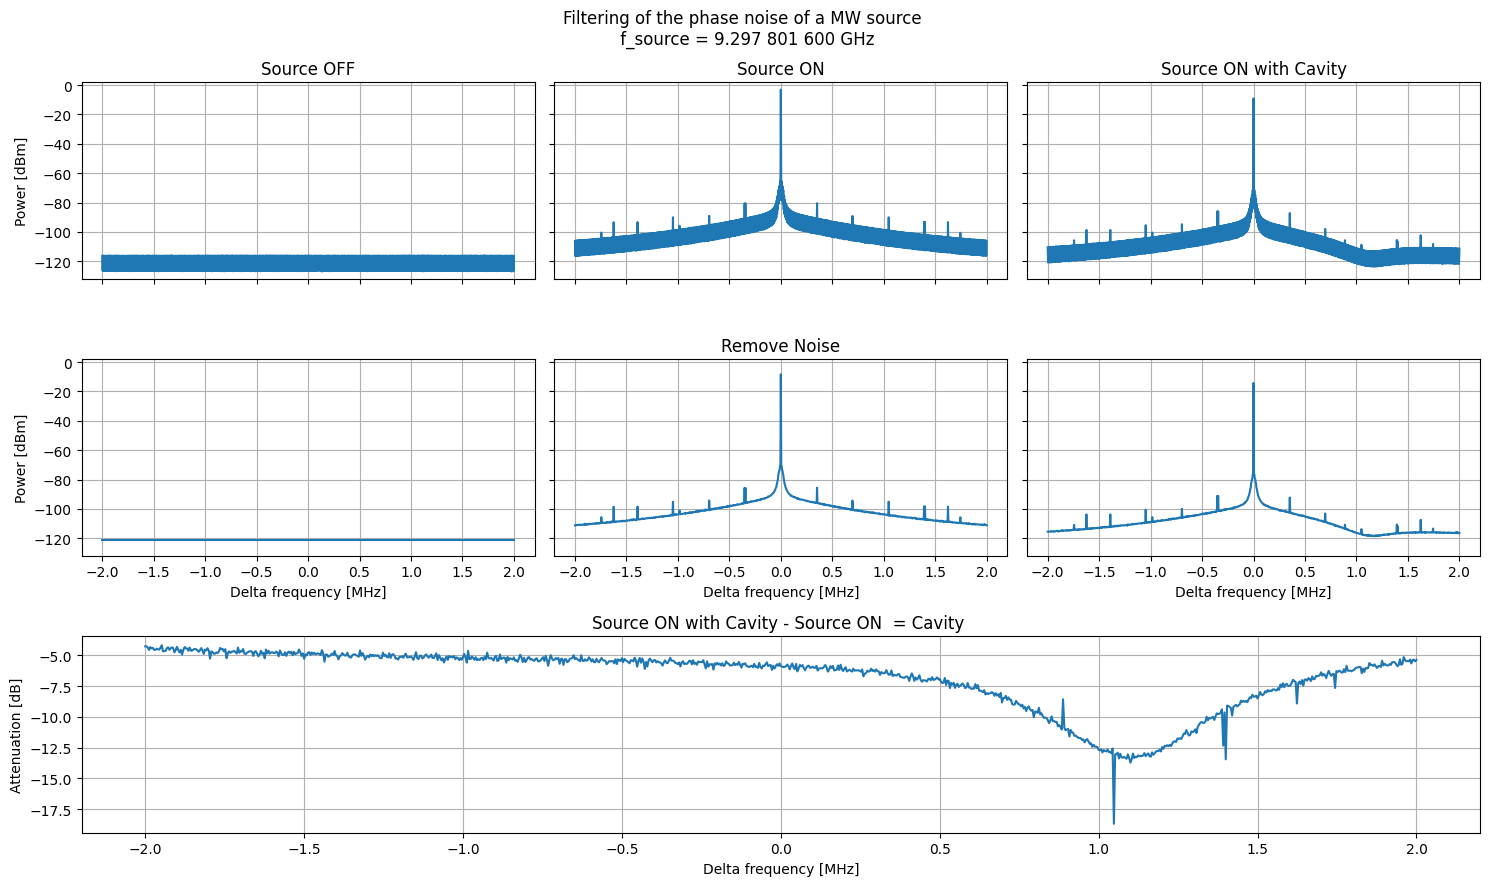

In [266]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(3, 3)

ax_off = fig.add_subplot(gs[0, 0])
ax_on = fig.add_subplot(gs[0, 1])
ax_cav = fig.add_subplot(gs[0, 2])

ax_off_ref = fig.add_subplot(gs[1, 0])
ax_on_ref = fig.add_subplot(gs[1, 1])
ax_cav_ref = fig.add_subplot(gs[1, 2])

ax_filter = fig.add_subplot(gs[2, :])

freq = data_sourceoff.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
off = data_sourceoff.spect.values
on = data_sourceon.spect.values
cavity = data_cavity.spect.values

ymin = np.min(off) - 5
ymax = np.max(on) + 5

ref = - np.mean(off)

ax_off.plot(delta_freq, off)
ax_on.plot(delta_freq, on)
ax_cav.plot(delta_freq, cavity)

ax_off_ref.plot(delta_freq, off - off - ref)
ax_on_ref.plot(delta_freq, on - off - ref)
ax_cav_ref.plot(delta_freq, cavity - off - ref)

ax_filter.plot(delta_freq, cavity - on)

ax_off.set_ylabel('Power [dBm]')
ax_off.set_ylim(ymin, ymax)
ax_off.set_xticklabels([])
ax_off.set_title('Source OFF')
ax_off.grid(True)
ax_on.set_ylim(ymin, ymax)
ax_on.set_xticklabels([])
ax_on.set_yticklabels([])
ax_on.set_title('Source ON')
ax_on.grid(True)
ax_cav.set_ylim(ymin, ymax)
ax_cav.set_xticklabels([])
ax_cav.set_yticklabels([])
ax_cav.set_title('Source ON with Cavity')
ax_cav.grid(True)

ax_off_ref.set_xlabel('Delta frequency [MHz]')
ax_off_ref.set_ylabel('Power [dBm]')
ax_off_ref.set_ylim(ymin, ymax)
ax_off_ref.grid(True)
ax_on_ref.set_xlabel('Delta frequency [MHz]')
ax_on_ref.set_ylim(ymin, ymax)
ax_on_ref.set_yticklabels([])
ax_on_ref.set_title('Remove Noise')
ax_on_ref.grid(True)
ax_cav_ref.set_xlabel('Delta frequency [MHz]')
ax_cav_ref.set_ylim(ymin, ymax)
ax_cav_ref.set_yticklabels([])
ax_cav_ref.grid(True)

ax_filter.set_xlabel('Delta frequency [MHz]')
ax_filter.set_ylabel('Attenuation [dB]')
ax_filter.set_title('Source ON with Cavity - Source ON  = Cavity ')
ax_filter.grid(True)

fig.suptitle('Filtering of the phase noise of a MW source \n f_source = 9.297 801 600 GHz')
fig.tight_layout()

# [0005-0006] Power sweep

Still use 0004 for the background noise

Sweep: -35dBm - +10dBm, 1dBm step

0005: With the cavity

0006: Without the cavity

In [267]:
file_folder = '2026-06-17_14.04.17_0004_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

data_sourceoff = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "trace"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


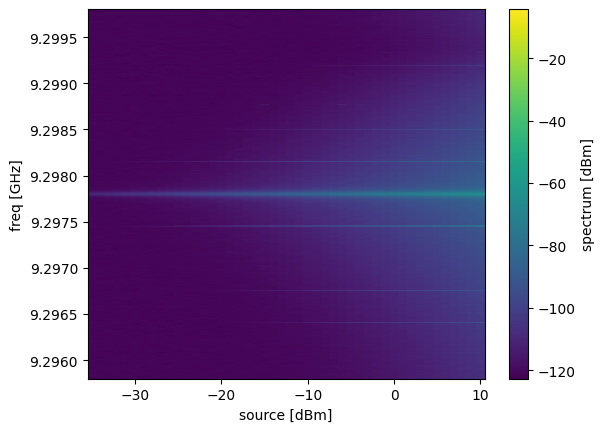

In [268]:
file_folder = '2026-06-17_16.48.25_0005_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'power':['source', 'dBm', 1]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)
shape = (len(data_cavity.freq.values), len(data_cavity.source.values))
data_cavity.spect.values = data_cavity.spect.values - np.repeat(data_sourceoff.spect.values[:, np.newaxis], shape[1], axis=1) + np.full(shape, np.mean(data_sourceoff.spect.values))
data_cavity.spect.plot(cmap='viridis')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


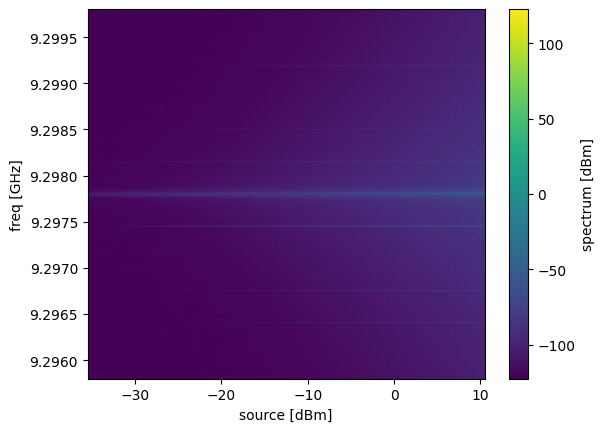

In [269]:
file_folder = '2026-06-17_17.23.40_0006_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'power':['source', 'dBm', 1]}

data_source = format_data_xarray(data, tool='SA', translator=translator)
shape = (len(data_source.freq.values), len(data_source.source.values))
data_source.spect.values = data_source.spect.values - np.repeat(data_sourceoff.spect.values[:, np.newaxis], shape[1], axis=1) + np.full(shape, np.mean(data_sourceoff.spect.values))
data_source.spect.plot(cmap='viridis')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


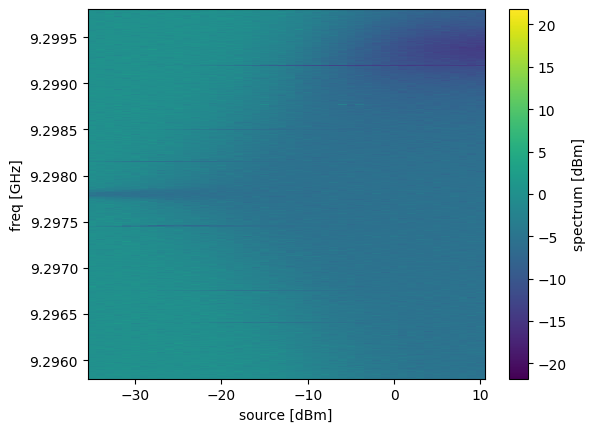

In [270]:
file_folder = '2026-06-17_17.23.40_0006_SA_Measurements'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'power':['source', 'dBm', 1]}

data_filter = format_data_xarray(data, tool='SA', translator=translator)
shape = (len(data_filter.freq.values), len(data_filter.source.values))
data_filter.spect.values = data_cavity.spect.values - data_source.spect.values
data_filter.spect.plot(cmap='viridis')
plt.show()

# Sarah's resonator

Cavity frequency: 9.301 542 07 GHz

Mechanic frequency: 1.210 881 MHz

Pump on the red sideband, and cavity tuned at the cavity frequency

In [271]:
fc = 9.30154207e+09
fm = 1.21e+06 + 881

## Background noise of the SA

In [292]:
file_folder = '2026-06-19_11.23.37_0009_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_11.23.37_0009_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_noise = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


## Spectrum of the source

In [293]:
file_folder = '2026-06-19_11.23.37_0009_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_11.17.30_0008_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_source = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


## Spectrum with the cavity

In [294]:
file_folder = '2026-06-19_11.23.37_0009_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_11.12.18_0007_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


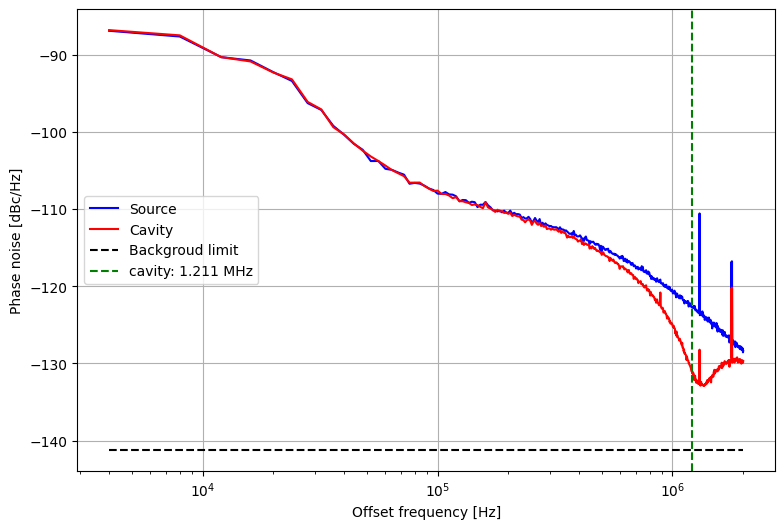

In [295]:
f_source = data_source.freq.values[np.argmax(data_source.spect.values)]

_source = data_source.sel(freq=slice(f_source + 1e-6, data_source.freq.values[-1]))
_cavity = data_cavity.sel(freq=slice(f_source + 1e-6, data_source.freq.values[-1]))
_noise = data_noise.sel(freq=slice(f_source + 1e-6, data_source.freq.values[-1]))

ref = np.mean(data_noise.spect.values)

dBm_max_source = np.max(data_source.spect.values)
dBm_max_cavity = np.max(data_cavity.spect.values)
bandwidth = 100

dBc_source = np.array(_source.spect.values - _noise.spect.values) + ref - dBm_max_source - 10*np.log10(bandwidth)
dBc_cavity = np.array(_cavity.spect.values - _noise.spect.values) + ref - dBm_max_cavity - 10*np.log10(bandwidth)
dBc_limit = np.full(len(_noise.freq.values), ref) - 10*np.log10(bandwidth)

plt.figure(figsize=(9,6))
plt.semilogx((np.array(_source.freq.values) - f_source)*1e+09, dBc_source, color='blue', label='Source')
plt.semilogx((np.array(_cavity.freq.values) - f_source)*1e+09, dBc_cavity, color='red', label='Cavity')
plt.semilogx((np.array(_noise.freq.values) - f_source)*1e+09, dBc_limit, color='black', linestyle='--', label='Backgroud limit')
plt.axvline(fm, color='green', linestyle='--', label=f'cavity: {fm*1e-6:.3f} MHz')
plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Phase noise [dBc/Hz]')
plt.legend()
plt.grid(True)
plt.show()

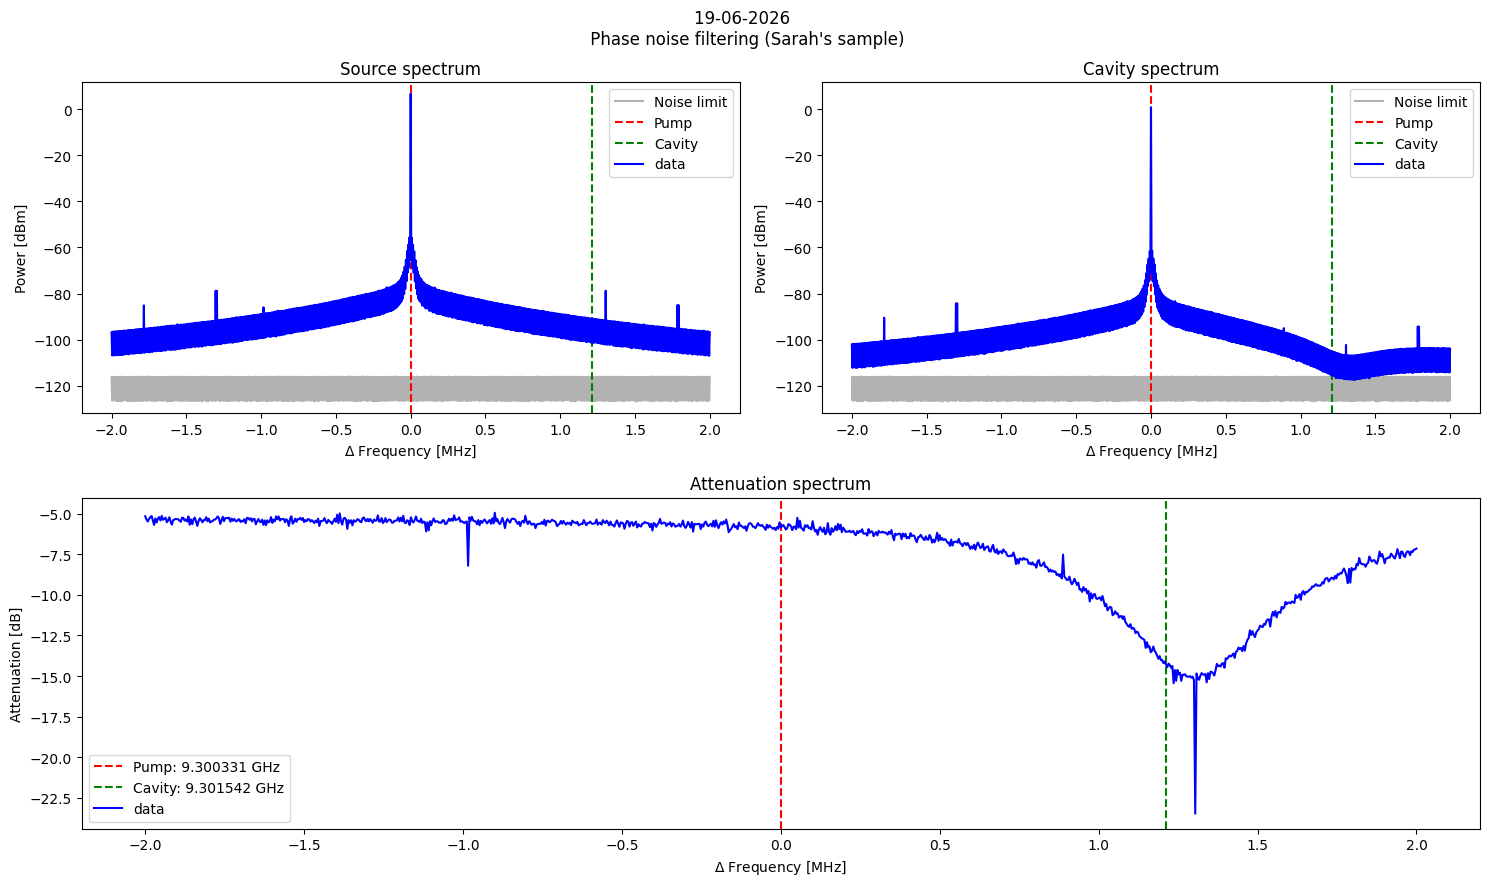

In [296]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 2)

ax_source = fig.add_subplot(gs[0, 0])
ax_cavity = fig.add_subplot(gs[0, 1])
ax_att = fig.add_subplot(gs[1, :])

freq = data_source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
noise = data_noise.spect.values
source = data_source.spect.values
cavity = data_cavity.spect.values

noise_level = np.mean(data_noise.spect.values)

ymin = np.min(data_noise.spect.values) - 5
ymax = np.max(source) + 5

ax_source.plot(delta_freq, noise, color='black', alpha = 0.3, label='Noise limit')
ax_source.axvline(0, color='red', linestyle='--', label='Pump')
ax_source.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_source.plot(delta_freq, source, color='blue', label='data')
ax_source.set_xlabel('$\Delta$ Frequency [MHz]')
ax_source.set_ylabel('Power [dBm]')
ax_source.set_ylim(ymin, ymax)
ax_source.set_title('Source spectrum')
ax_source.legend()

ax_cavity.plot(delta_freq, noise, color='black', alpha = 0.3, label='Noise limit')
ax_cavity.axvline(0, color='red', linestyle='--', label='Pump')
ax_cavity.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_cavity.plot(delta_freq, cavity, color='blue', label='data')
ax_cavity.set_xlabel('$\Delta$ Frequency [MHz]')
ax_cavity.set_ylabel('Power [dBm]')
ax_cavity.set_ylim(ymin, ymax)
ax_cavity.set_title('Cavity spectrum')
ax_cavity.legend()

ax_att.axvline(0, color='red', linestyle='--', label=f'Pump: {(fc - fm)*1e-09:.6f} GHz')
ax_att.axvline(fm * 1e-6, color='green', linestyle='--', label=f'Cavity: {fc*1e-09:.6f} GHz')
ax_att.plot(delta_freq, cavity - source, color='blue', label='data')
ax_att.set_xlabel('$\Delta$ Frequency [MHz]')
ax_att.set_ylabel('Attenuation [dB]')
ax_att.set_title('Attenuation spectrum')
ax_att.legend()

fig.suptitle(f"19-06-2026 \n Phase noise filtering (Sarah's sample)")
fig.tight_layout()

In [297]:
def lorentzian(freq, offset, depth, f0, kt):
    
    return offset - depth / (1 + ((freq - f0) / kt)**2)


def fit_lorentzian_dip(freq, dB):
    
    lin_scale = 10**(dB / 10)

    # Estimations initiales
    offset_guess = np.max(lin_scale)
    f0_guess = freq[np.argmin(lin_scale)]
    depth_guess = offset_guess - np.min(lin_scale)
    kt_guess = (np.max(freq) - np.min(freq)) / 6

    p0 = [offset_guess, depth_guess, f0_guess, kt_guess]

    popt, pcov = curve_fit(lorentzian, freq, lin_scale, p0=p0)

    offset, depth, f0, kt = popt

    results = {
        "f0": f0,
        "kt": 2 * abs(kt),
        "depth": depth,
        "offset": offset,
        "popt": popt,
        "pcov": pcov
    }

    return results

Frequency: 1.316 MHz
kappa_tot: 1.086 MHz
Depth: 10.073 dB


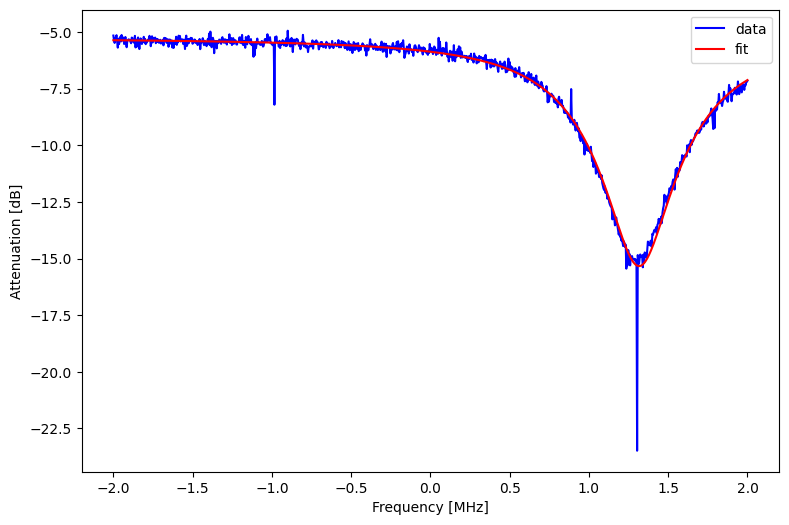

In [298]:
freq = data_source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
source = data_source.isel(source=0).spect.values
cavity = data_cavity.isel(source=0).spect.values

result = fit_lorentzian_dip(np.array(delta_freq), np.array(cavity - source))
popt = result['popt']
plt.figure(figsize=(9, 6))
plt.plot(np.array(delta_freq), np.array(cavity - source), color='blue', label='data')
plt.plot(np.array(delta_freq), 10*np.log10(lorentzian(np.array(delta_freq), *popt)), color='red', label='fit')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Attenuation [dB]')
plt.legend()
plt.plot()

print(f"Frequency: {result['f0']:.3f} MHz")
print(f"kappa_tot: {result['kt']:.3f} MHz")
print(f"Depth: {np.abs(10*np.log10((result['offset'] - result['depth'])/result['offset'])):.3f} dB")

## Spectrum with cavity (30dB dip)

In [280]:
file_folder = '2026-06-19_15.15.06_0010_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_15.15.06_0010_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


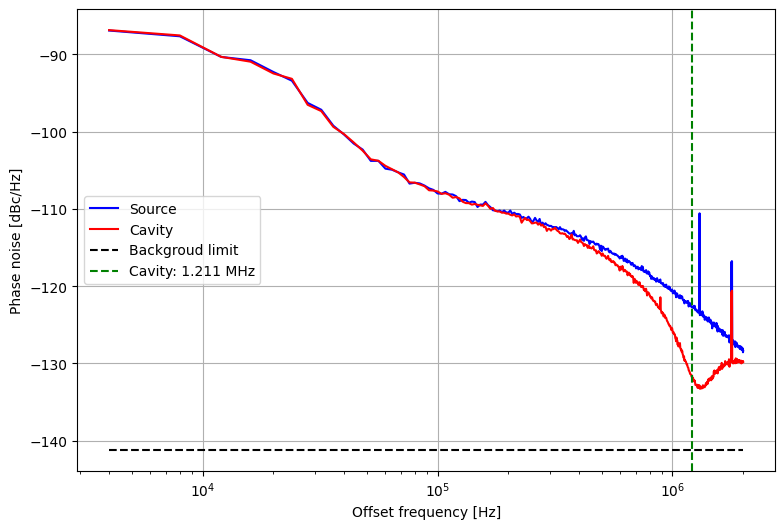

In [281]:
f_source = data_source.freq.values[np.argmax(data_source.spect.values)]

_source = data_source.sel(freq=slice(f_source + 1e-6, data_source.freq.values[-1]))
_cavity = data_cavity.sel(freq=slice(f_source + 1e-6, data_source.freq.values[-1]))
_noise = data_noise.sel(freq=slice(f_source + 1e-6, data_source.freq.values[-1]))

ref = np.mean(data_noise.spect.values)

dBm_max_source = np.max(data_source.spect.values)
dBm_max_cavity = np.max(data_cavity.spect.values)
bandwidth = 100

dBc_source = np.array(_source.spect.values - _noise.spect.values) + ref - dBm_max_source - 10*np.log10(bandwidth)
dBc_cavity = np.array(_cavity.spect.values - _noise.spect.values) + ref - dBm_max_cavity - 10*np.log10(bandwidth)
dBc_limit = np.full(len(_noise.freq.values), ref) - 10*np.log10(bandwidth)

plt.figure(figsize=(9,6))
plt.semilogx((np.array(_source.freq.values) - f_source)*1e+09, dBc_source, color='blue', label='Source')
plt.semilogx((np.array(_cavity.freq.values) - f_source)*1e+09, dBc_cavity, color='red', label='Cavity')
plt.semilogx((np.array(_noise.freq.values) - f_source)*1e+09, dBc_limit, color='black', linestyle='--', label='Backgroud limit')
plt.axvline(fm, color='green', linestyle='--', label=f'Cavity: {fm*1e-6:.3f} MHz')
plt.xlabel('Offset frequency [Hz]')
plt.ylabel('Phase noise [dBc/Hz]')
plt.legend()
plt.grid(True)
plt.show()

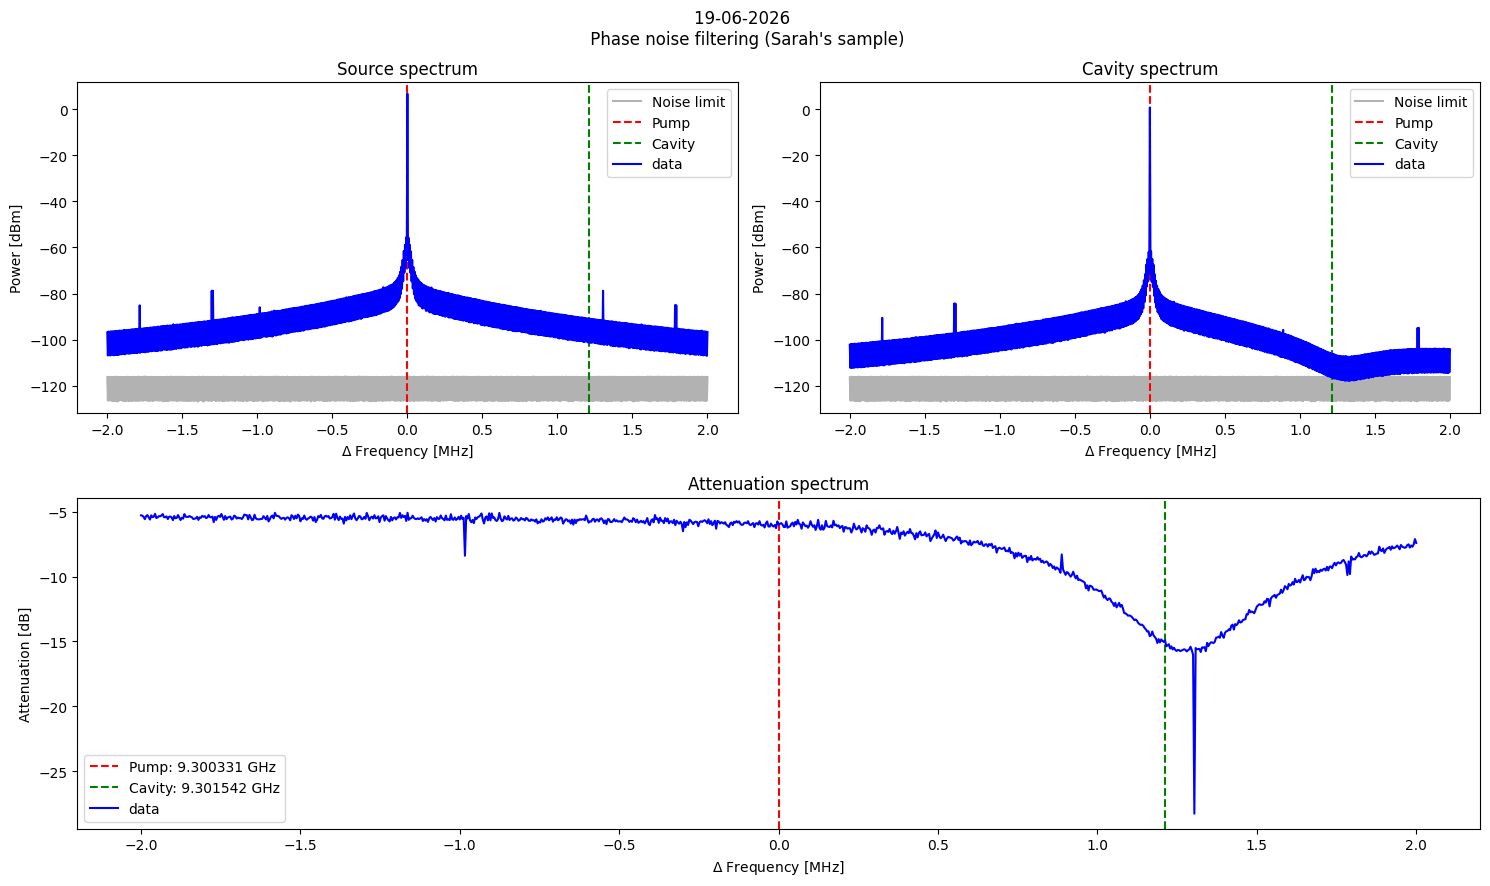

In [282]:
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 2)

ax_source = fig.add_subplot(gs[0, 0])
ax_cavity = fig.add_subplot(gs[0, 1])
ax_att = fig.add_subplot(gs[1, :])

freq = data_source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
noise = data_noise.spect.values
source = data_source.spect.values
cavity = data_cavity.spect.values

noise_level = np.mean(data_noise.spect.values)

ymin = np.min(data_noise.spect.values) - 5
ymax = np.max(source) + 5

ax_source.plot(delta_freq, noise, color='black', alpha = 0.3, label='Noise limit')
ax_source.axvline(0, color='red', linestyle='--', label='Pump')
ax_source.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_source.plot(delta_freq, source, color='blue', label='data')
ax_source.set_xlabel('$\Delta$ Frequency [MHz]')
ax_source.set_ylabel('Power [dBm]')
ax_source.set_ylim(ymin, ymax)
ax_source.set_title('Source spectrum')
ax_source.legend()

ax_cavity.plot(delta_freq, noise, color='black', alpha = 0.3, label='Noise limit')
ax_cavity.axvline(0, color='red', linestyle='--', label='Pump')
ax_cavity.axvline(fm * 1e-6, color='green', linestyle='--', label='Cavity')
ax_cavity.plot(delta_freq, cavity, color='blue', label='data')
ax_cavity.set_xlabel('$\Delta$ Frequency [MHz]')
ax_cavity.set_ylabel('Power [dBm]')
ax_cavity.set_ylim(ymin, ymax)
ax_cavity.set_title('Cavity spectrum')
ax_cavity.legend()

ax_att.axvline(0, color='red', linestyle='--', label=f'Pump: {(fc - fm)*1e-09:.6f} GHz')
ax_att.axvline(fm * 1e-6, color='green', linestyle='--', label=f'Cavity: {fc*1e-09:.6f} GHz')
ax_att.plot(delta_freq, cavity - source, color='blue', label='data')
ax_att.set_xlabel('$\Delta$ Frequency [MHz]')
ax_att.set_ylabel('Attenuation [dB]')
ax_att.set_title('Attenuation spectrum')
ax_att.legend()

fig.suptitle(f"19-06-2026 \n Phase noise filtering (Sarah's sample)")
fig.tight_layout()

Frequency: 1.298 MHz
kappa_tot: 1.182 MHz
Depth: 10.655 dB


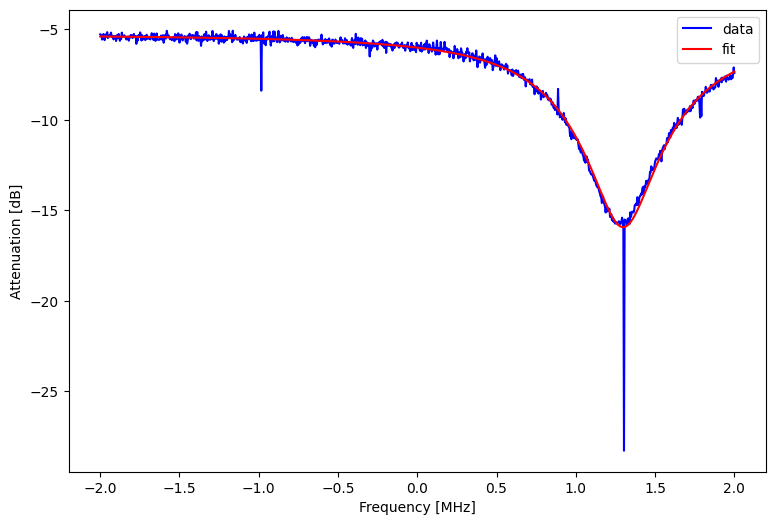

In [283]:
freq = data_source.freq.values
delta_freq = (freq - freq[len(freq)//2])*1e3 # MHz
source = data_source.isel(source=0).spect.values
cavity = data_cavity.isel(source=0).spect.values

result = fit_lorentzian_dip(np.array(delta_freq), np.array(cavity - source))

print(f"Frequency: {result['f0']:.3f} MHz")
print(f"kappa_tot: {result['kt']:.3f} MHz")
print(f"Depth: {np.abs(10*np.log10((result['offset'] - result['depth'])/result['offset'])):.3f} dB")

## Sweep power (-10 dBm to +10 dBm)

0011: sweep cavity

0012: sweep source

0013: noise

In [300]:
file_folder = '2026-06-19_16.59.45_0013_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_16.59.45_0013_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_noise = format_data_xarray(data, tool='SA', translator=translator)

ref = np.mean(data_noise.spect.values)

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


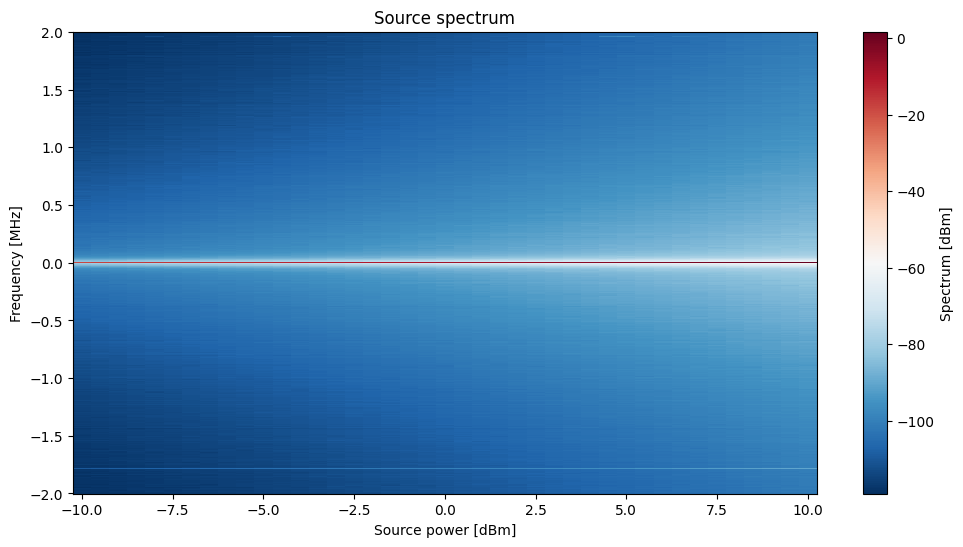

In [301]:
file_folder = '2026-06-19_16.25.31_0012_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_16.25.31_0012_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_source = format_data_xarray(data, tool='SA', translator=translator)
plt.figure(figsize=(12, 6))
plt.pcolormesh(data_source.source.values, (data_source.freq.values - (fc - fm)*1e-09)*1e+03, data_source.spect.values - data_noise.spect.values + ref,
               shading='auto', cmap = 'RdBu_r')
plt.colorbar(label = 'Spectrum [dBm]')
plt.xlabel('Source power [dBm]')
plt.ylabel('Frequency [MHz]')
plt.title('Source spectrum')
plt.show()

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'source']


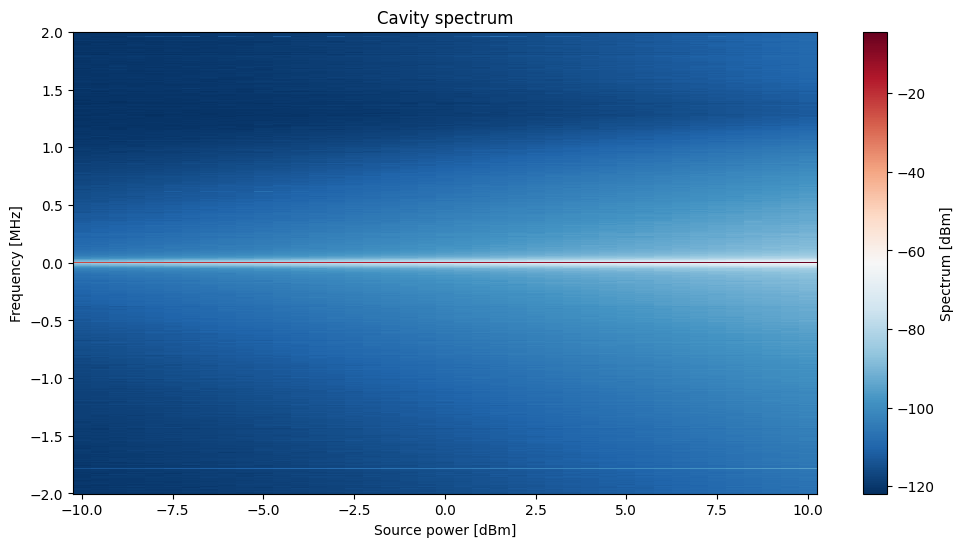

In [302]:
file_folder = '2026-06-19_15.56.16_0011_SA_Measurements'
full_path = base_folder + '/' + file_folder
full_path = '/home/jovyan/internship_pacome_github/internship-pacome/Cavity_measurements/Data_SA/2026-06-19_15.56.16_0011_SA_Measurements'
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=0)
data

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
             'power':['source', 'dBm', 1]}

data_cavity = format_data_xarray(data, tool='SA', translator=translator)
#data_cavity.spect.plot(cmap='viridis', vmin = np.min(data_cavity.spect.values), vmax=np.max(data_cavity.spect.values))
#plt.tight_layout()

plt.figure(figsize=(12, 6))
plt.pcolormesh(data_cavity.source.values, (data_cavity.freq.values - (fc - fm)*1e-09)*1e+03, data_cavity.spect.values - data_noise.spect.values + ref,
               shading='auto', cmap = 'RdBu_r')
plt.colorbar(label = 'Spectrum [dBm]')
plt.xlabel('Source power [dBm]')
plt.ylabel('Frequency [MHz]')
plt.title('Cavity spectrum')
plt.show()

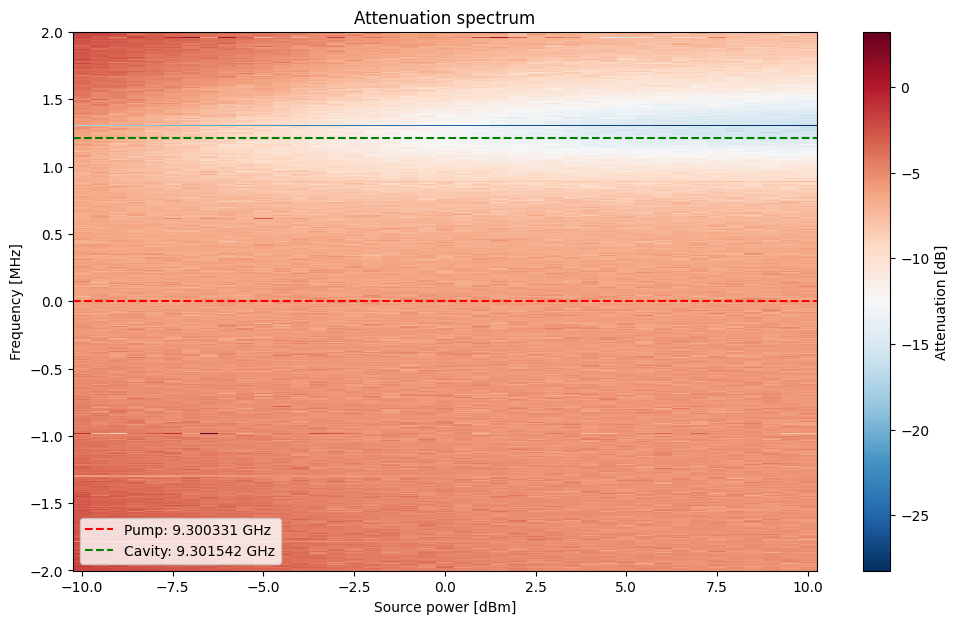

In [346]:
plt.figure(figsize=(12, 7))
plt.pcolormesh(data_cavity.source.values, (data_cavity.freq.values - (fc - fm)*1e-09)*1e+03, data_cavity.spect.values - data_source.spect.values,
               shading='auto', cmap = 'RdBu_r')
plt.axhline(0, color='red', linestyle='--', label=f'Pump: {(fc-fm)*1e-09:.6f} GHz')
plt.axhline(fm*1e-6, color='green', linestyle='--', label=f'Cavity: {fc*1e-9:.6f} GHz')
plt.colorbar(label = 'Attenuation [dB]')
plt.xlabel('Source power [dBm]')
plt.ylabel('Frequency [MHz]')
plt.legend(loc='lower left')
plt.title('Attenuation spectrum')
plt.show()

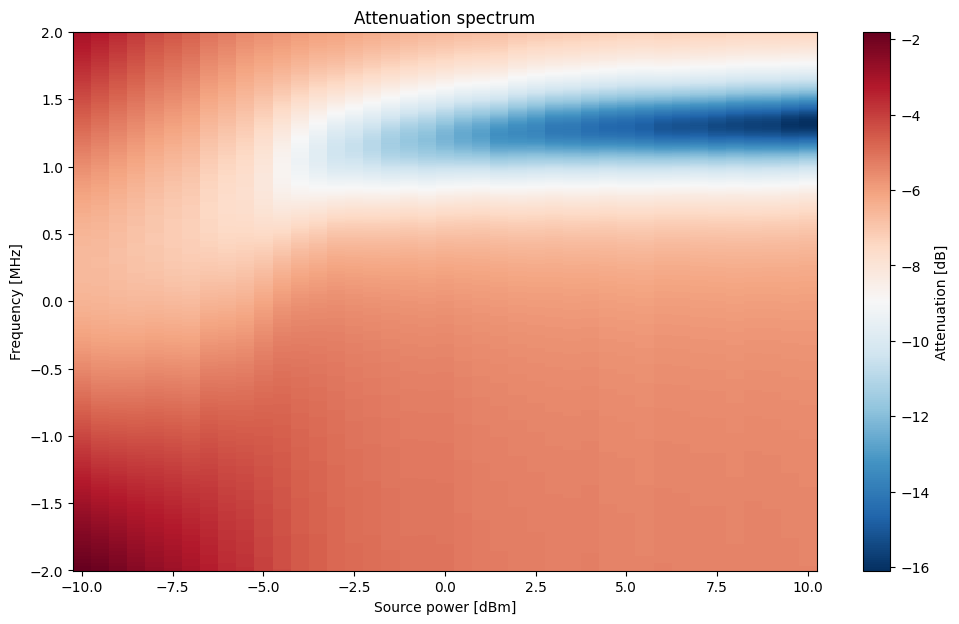

In [335]:
data_cavity.source.values
(data_cavity.freq.values - (fc - fm)*1e-09)*1e+03
data_cavity.spect.values - data_source.spect.values,

sources = data_cavity.source.values
freqs = data_cavity.freq.values
delta_freqs = (freqs - freqs[len(freq)//2]) * 1e+03

result_fit = {}
color_plot = []

for source in sources:
    data_fit = data_cavity.sel(source = source).spect.values - data_source.sel(source = source).spect.values
    fit = fit_lorentzian_dip(np.array(delta_freqs), np.array(data_fit))
    result_fit[source] = fit
    popt = fit['popt']
    color_plot.append(10*np.log10(lorentzian(np.array(delta_freq), *popt)))

plt.figure(figsize=(12, 7))
plt.pcolormesh(sources, delta_freqs, np.array(color_plot).T,
               shading='auto', cmap = 'RdBu_r')
plt.colorbar(label = 'Attenuation [dB]')
plt.xlabel('Source power [dBm]')
plt.ylabel('Frequency [MHz]')
plt.title('Attenuation spectrum')
plt.show()